In [1]:
# Forecasting and machine-learning notebook that trains an LSTM
# (Long Short-Term Memory) model on the merged atmospheric dataset
# containing 30+ turbulence, weather, and seeing parameters collected
# across multiple years.
#
# The model learns temporal patterns and long-term relationships within
# the historical data to generate next-day forecasts, effectively asking:
# “Given how previous years behaved, what might tomorrow look like?”
#
# The notebook includes data preprocessing, feature scaling, sequence
# construction, model training, validation, and prediction workflows for
# multivariate time-series forecasting of atmospheric conditions and
# turbulence behavior.


import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

In [2]:
# Step 1 - Load data 
file2019 = "./years_merged/2019_merged.csv"
file2020 = "./years_merged/2020_merged.csv"

df_2019 = pd.read_csv(file2019)
df_2020 = pd.read_csv(file2020)

In [3]:
# Step 2 - Convert timestamps 
df_2019["dimm_time"] = pd.to_datetime(
    df_2019["dimm_time"]
)

df_2020["dimm_time"] = pd.to_datetime(
    df_2020["dimm_time"]
)

In [4]:
# Step 3 - Clean missing data
df_2019 = df_2019.interpolate().dropna()
df_2020 = df_2020.interpolate().dropna()

In [5]:
# Step 4 - Add time features
df_2019["hour"] = df_2019["dimm_time"].dt.hour
df_2020["hour"] = df_2020["dimm_time"].dt.hour

In [6]:
# Step 5 - Cyclical time encoding
df_2019["hour_sin"] = np.sin(
    2 * np.pi * df_2019["hour"] / 24
)
df_2019["hour_cos"] = np.cos(
    2 * np.pi * df_2019["hour"] / 24
)
df_2020["hour_sin"] = np.sin(
    2 * np.pi * df_2020["hour"] / 24
)
df_2020["hour_cos"] = np.cos(
    2 * np.pi * df_2020["hour"] / 24
)

In [7]:
# Step 6 - Choose features
features = [
    "dimm_val",
    "mass_val",
    "wind_speed",
    "temp",
    "humidity",
    "hour_sin",
    "hour_cos"
]

In [8]:
# Step 7 - Scale data
scaler = StandardScaler()

scaled_2019 = scaler.fit_transform(
    df_2019[features]
)
scaled_2020 = scaler.transform(
    df_2020[features]
)

In [9]:
# Step 8 - Create training sequences 
SEQ_LEN = 60

X_train = []
y_train = []

for i in range(SEQ_LEN, len(scaled_2019)):

    X_train.append(
        scaled_2019[i-SEQ_LEN:i]
    )

    y_train.append(
        scaled_2019[i, 0]
    )

X_train = np.array(X_train)

y_train = np.array(y_train)

In [10]:
# Step 9 - Create testing sequences
X_test = []
y_test = []

for i in range(SEQ_LEN, len(scaled_2020)):

    X_test.append(
        scaled_2020[i-SEQ_LEN:i]
    )

    y_test.append(
        scaled_2020[i, 0]
    )

X_test = np.array(X_test)

y_test = np.array(y_test)

In [11]:
# Step 10 - Convert to PyTorch tensors
X_train = torch.tensor(
    X_train,
    dtype=torch.float32
)
y_train = torch.tensor(
    y_train,
    dtype=torch.float32
)
X_test = torch.tensor(
    X_test,
    dtype=torch.float32
)
y_test = torch.tensor(
    y_test,
    dtype=torch.float32
)

In [12]:
# Step 11 - Create DataLoader
train_dataset = TensorDataset(
    X_train,
    y_train
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

In [13]:
# Step 12 - Define model
class ForecastLSTM(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(64, 1)

    def forward(self, x):

        out, _ = self.lstm(x)

        out = out[:, -1, :]

        out = self.fc(out)

        return out

In [14]:
# Step 13 - Create model
model = ForecastLSTM(
    input_size=X_train.shape[2]
)

In [15]:
# Step 14 - Loss and Optimizer
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [16]:
# Step 15 - Faster mini-batch training
EPOCHS = 20

losses = []

for epoch in range(EPOCHS):

    model.train()

    epoch_loss = 0

    for batch_X, batch_y in train_loader:

        optimizer.zero_grad()

        outputs = model(batch_X).squeeze()

        loss = criterion(
            outputs,
            batch_y
        )

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    losses.append(avg_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS}, "
        f"Loss: {avg_loss:.6f}"
    )

Epoch 1/20, Loss: 0.329100
Epoch 2/20, Loss: 0.214929
Epoch 3/20, Loss: 0.211893
Epoch 4/20, Loss: 0.209661
Epoch 5/20, Loss: 0.210226
Epoch 6/20, Loss: 0.208576
Epoch 7/20, Loss: 0.207923
Epoch 8/20, Loss: 0.207098
Epoch 9/20, Loss: 0.206835
Epoch 10/20, Loss: 0.206834
Epoch 11/20, Loss: 0.204897
Epoch 12/20, Loss: 0.205704
Epoch 13/20, Loss: 0.204048
Epoch 14/20, Loss: 0.203452
Epoch 15/20, Loss: 0.203578
Epoch 16/20, Loss: 0.202572
Epoch 17/20, Loss: 0.203273
Epoch 18/20, Loss: 0.201051
Epoch 19/20, Loss: 0.199833
Epoch 20/20, Loss: 0.200991


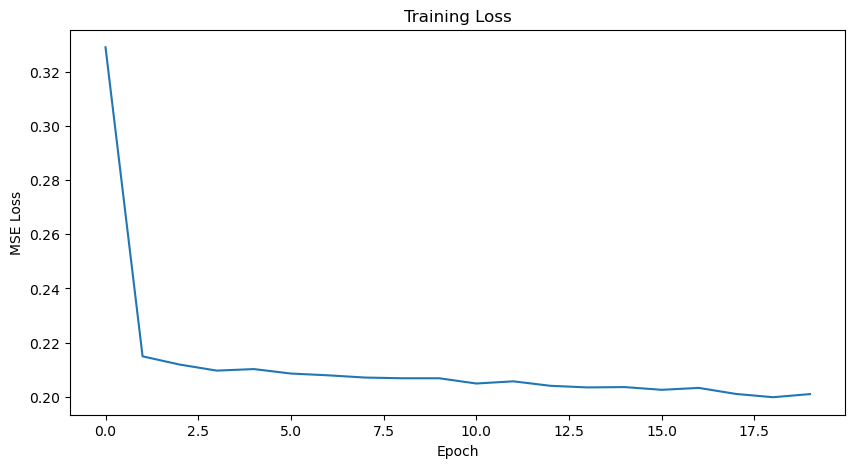

In [17]:
# Step 16 - Plot training loss
plt.figure(figsize=(10,5))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

In [18]:
# Step 17 - Generate predictions for 2020
model.eval()

with torch.no_grad():

    predictions = model(
        X_test
    ).squeeze()

In [19]:
# Step 18 - Convert Predictions to NumPy
predictions = predictions.numpy()
actual = y_test.numpy()

In [20]:
# Step 19 - Compute RMSE
rmse = np.sqrt(
    mean_squared_error(
        actual,
        predictions
    )
)

print("LSTM RMSE:", rmse)

LSTM RMSE: 0.5539239275308027


In [21]:
# Step 20 - Persistence baseline
baseline = actual[:-1]

truth = actual[1:]

baseline_rmse = np.sqrt(
    mean_squared_error(
        truth,
        baseline
    )
)

print(
    "Persistence RMSE:",
    baseline_rmse
)

Persistence RMSE: 0.6122908400531842


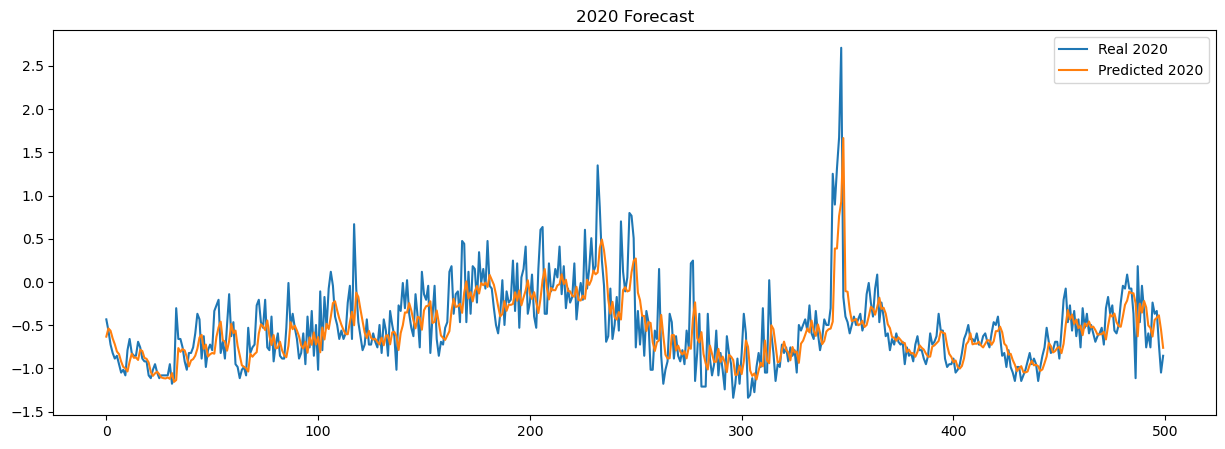

In [22]:
# Step 21 - Plot 2020 predictions 
plt.figure(figsize=(15,5))
plt.plot(
    actual[:500],
    label="Real 2020"
)

plt.plot(
    predictions[:500],
    label="Predicted 2020"
)
plt.legend()
plt.title("2020 Forecast")
plt.show()